# 46 — 3D convolution and spatiotemporal receptive fields

Lecture 10 extends image convolutions into **time**. A 3D CNN can learn local patterns across frames and spatial locations using filters that slide over all three axes.

This practice has five focused exercises:
1. calculate output dimensions;
2. trace one tiny temporal convolution;
3. implement a naïve NumPy forward pass;
4. check it against PyTorch;
5. build a simple direction-sensitive temporal filter.

We will use very small arrays so every axis and sum can be inspected. A later notebook will train video classifiers.

Based on [CS231n Spring 2025 Lecture 10](https://cs231n.stanford.edu/2025/schedule.html) and the lecture references saved in `notes/_references/10-video/`.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

np.random.seed(7)
torch.manual_seed(7)

### What is a filter bank?

A **filter bank** is simply the collection of all filters in one convolutional layer. One filter produces one output channel, so a layer with $C_{out}$ output channels contains $C_{out}$ filters. For 3D convolution, each filter has shape $(C_{in},K_t,K_h,K_w)$, and the complete filter bank has shape $(C_{out},C_{in},K_t,K_h,K_w)$. The word *bank* is not specific to 3D convolution; the same term is used for collections of 1D and 2D filters.

## 1. From 2D to 3D convolution

A PyTorch video batch has shape `(N, C_in, T, H, W)`. A 3D filter bank has shape `(C_out, C_in, K_t, K_h, K_w)`. Its output is `(N, C_out, T_out, H_out, W_out)`.

At each output location, one filter multiplies a `(C_in,K_t,K_h,K_w)` input patch and sums **all** those values, then adds one bias for its output channel. This is the same dot-product idea as 2D convolution, with an additional kernel-time axis.

For each dimension $D\in\{T,H,W\}$, with kernel size $K$, padding $P$, stride $S$, and dilation 1:

$$D_{\text{out}}=\left\lfloor\frac{D+2P-K}{S}\right\rfloor+1.$$

The formula must be applied separately to time, height, and width. A filter `(3,3,3)` sees three frames and a 3×3 spatial patch; it does not see the complete video.

### Exercise 1 — Calculate three output dimensions

Use `(N,C,T,H,W)=(2,3,8,16,20)`, four output filters, kernel `(3,3,5)`, padding `(1,1,2)`, and stride `(2,2,2)`. Predict the shape before running the check.

In [14]:
def conv3d_output_dim(input_size, kernel_size, padding=0, stride=1):
    """Return one dimension of a valid 3D-convolution output."""
    if input_size <= 0 or kernel_size <= 0 or padding < 0 or stride <= 0:
        raise ValueError("sizes and stride must be positive; padding nonnegative")
    # apply floor((input_size + 2*padding - kernel_size)/stride) + 1.
    # output_size = np.floor(((input_size + 2*padding - kernel_size)/stride) + 1)
    output_size = (
        input_size + 2 * padding - kernel_size
    ) // stride + 1
    if output_size <= 0:
        raise ValueError("kernel does not fit the padded input")
    return output_size

time_out = conv3d_output_dim(8, 3, padding=1, stride=2)
height_out = conv3d_output_dim(16, 3, padding=1, stride=2)
width_out = conv3d_output_dim(20, 5, padding=2, stride=2)
predicted_shape = (2, 4, time_out, height_out, width_out)
assert predicted_shape == (2, 4, 4, 8, 10)
print("Output shape:", predicted_shape)

Output shape: (2, 4, 4, 8, 10)


## 2. Trace one temporal filter by hand

Remove spatial complexity by making height and width equal to 1. The input $x=(1,2,4)$ represents the value of the **same pixel** in three successive video frames: the pixel becomes brighter over time. Although we write only the changing values, its complete input shape is $(N,C,T,H,W)=(1,1,3,1,1)$.

The filter $w=(1,0,-1)$ also covers three time steps. Its complete shape is $(C_{out},C_{in},K_t,K_h,K_w)=(1,1,3,1,1)$. The first temporal value receives weight $1$, the middle value is ignored by weight $0$, and the last receives weight $-1$.

At one output position, convolution aligns the input patch and filter, multiplies corresponding values, and sums all products:

```text
input x:    1   2   4
filter w:   1   0  -1
products:   1   0  -4
```

Therefore the output activation $y$ is

$$y=1\cdot1+2\cdot0+4\cdot(-1)=1+0-4=-3.$$

There is only one possible filter position, so the output contains one value. This particular filter computes *first frame minus last frame*. Reversing the input to $(4,2,1)$ gives $4-1=3$, so the sign changes even though the sequence contains the same values. This demonstrates how a temporal filter can respond to frame order. A learned filter need not ignore the middle frame; these weights were chosen only to make the calculation transparent.

PyTorch's `Conv3d` computes cross-correlation: it uses the stored filter order directly rather than reversing the filter before multiplication. This matches our earlier naïve convolution implementation.

### Exercise 2 — Extract and multiply the tiny patch

Make `(1,1,3,1,1)` input and `(1,1,3,1,1)` weight arrays. Multiply corresponding entries and sum the channel, temporal, and spatial patch axes.

In [15]:
tiny_input = np.array([1.0, 2.0, 4.0]).reshape(1, 1, 3, 1, 1)
tiny_weight = np.array([1.0, 0.0, -1.0]).reshape(1, 1, 3, 1, 1)

# select the only (C_in, K_t, K_h, K_w) patch and filter.
tiny_patch = tiny_input[0]
tiny_filter = tiny_weight[0]
# elementwise multiply and sum every patch axis.
# tiny_result = np.sum(tiny_patch*tiny_filter, axis=(0,1,2,3))
tiny_result = np.sum(tiny_patch * tiny_filter)

assert tiny_patch.shape == tiny_filter.shape == (1, 3, 1, 1)
np.testing.assert_allclose(tiny_result, -3.0)
print("Tiny 3D-convolution output:", tiny_result)

Tiny 3D-convolution output: -3.0


## 3. A naïve 3D-convolution forward pass

For output frame $t$, row $i$, column $j$, and output channel $f$:

$$Y_{n,f,t,i,j}=\sum_{c,u,v,w} X_{n,c,tS_t+u,iS_h+v,jS_w+w}\,W_{f,c,u,v,w}+b_f.$$

Here $c$ is input channel; $u$ is offset **within the temporal kernel**; $v,w$ are spatial offsets. The output coordinates $t,i,j$ locate where the filter starts. Padding changes the input to a padded array, but the same indexing rule then applies.

To keep this first implementation readable, use one integer stride and one integer padding on all three axes. More general independent strides/paddings can be added when we extract reusable code.

### Exercise 3 — Implement `conv3d_forward_naive`



In [18]:
def conv3d_forward_naive(x, weights, bias, stride=1, padding=0):
    """Compute cross-correlation for NCTHW input and OI(Kt)(Kh)(Kw) filters."""
    x = np.asarray(x)
    weights = np.asarray(weights)
    bias = np.asarray(bias)
    if x.ndim != 5 or weights.ndim != 5:
        raise ValueError("x and weights must both have five axes")
    if x.shape[1] != weights.shape[1] or bias.shape != (weights.shape[0],):
        raise ValueError("input channels and filter biases must match")
    if stride <= 0 or padding < 0:
        raise ValueError("stride must be positive and padding nonnegative")

    n_count, _, input_t, input_h, input_w = x.shape
    filter_count, _, kernel_t, kernel_h, kernel_w = weights.shape
    output_t = conv3d_output_dim(input_t, kernel_t, padding, stride)
    output_h = conv3d_output_dim(input_h, kernel_h, padding, stride)
    output_w = conv3d_output_dim(input_w, kernel_w, padding, stride)

    padded = np.pad(
        x,
        ((0, 0), (0, 0), (padding, padding), (padding, padding), (padding, padding)),
    )
    output = np.empty(
        (n_count, filter_count, output_t, output_h, output_w),
        dtype=np.result_type(x, weights, bias, np.float32),
    )

    for n in range(n_count):
        for f in range(filter_count):
            for t in range(output_t):
                for i in range(output_h):
                    for j in range(output_w):
                        t_start, h_start, w_start = t * stride, i * stride, j * stride
                        # extract all input channels and the temporal/spatial
                        # patch beginning at (t_start, h_start, w_start).
                        patch = padded[
                            n,
                            :,
                            t_start:t_start+kernel_t,
                            h_start:h_start+kernel_h,
                            w_start:w_start+kernel_w,
                        ]
                        # multiply with weights[f], sum all patch axes, add bias[f].
                        output[n, f, t, i, j] = (
                            np.sum(patch * weights[f]) + bias[f]
                        )
                        # The resulting shapes are
                        # patch       (C_in, K_t, K_h, K_w)
                        # weights[f]  (C_in, K_t, K_h, K_w)
    return output

tiny_forward = conv3d_forward_naive(
    tiny_input, tiny_weight, np.array([0.0])
)
assert tiny_forward.shape == (1, 1, 1, 1, 1)
np.testing.assert_allclose(tiny_forward[0, 0, 0, 0, 0], -3.0)

## 4. Check against PyTorch

A direct implementation is excellent for reasoning but slow: Python loops visit every output position. `torch.nn.functional.conv3d` computes the same cross-correlation efficiently.

We will compare outputs on a small random case with nonzero padding and stride. This is a **forward correctness check**, not yet a backward gradient check.

### Exercise 4 — Compare numerical outputs

In [23]:
rng = np.random.default_rng(11)
x = rng.normal(size=(2, 2, 4, 5, 6))
weights = rng.normal(size=(3, 2, 2, 3, 3))
bias = rng.normal(size=(3,))
stride=2
padding=1
naive_output = conv3d_forward_naive(x, weights, bias, stride=stride, padding=padding)

# convert x, weights, and bias to PyTorch tensors without changing
# their dtype, then call F.conv3d with the same stride and padding.
torch_output = torch.nn.functional.conv3d(
    torch.from_numpy(x),
    torch.from_numpy(weights),
    torch.from_numpy(bias),
    stride=stride,
    padding=padding,
)

assert naive_output.shape == (2, 3, 3, 3, 3)
np.testing.assert_allclose(naive_output, torch_output.numpy(), rtol=1e-12, atol=1e-12)
print("Maximum absolute difference:", np.max(np.abs(naive_output - torch_output.numpy())))

Maximum absolute difference: 1.7763568394002505e-15


## 5. A filter that reacts to frame order

A temporal kernel `[-1, 1]` calculates a local **next minus current** change. For a bright square moving right, at a fixed pixel it responds positively when the square enters and negatively when the square leaves. Reversing frame order flips these local signs.

This is a simple hand-designed temporal difference filter. A trained 3D CNN learns many filters over *space and time* simultaneously, rather than relying on a single fixed-pixel difference. The key property is reuse: the same kernel slides through every temporal position.

### Exercise 5 — Apply the temporal-difference filter

Use the right/left pair from [Notebook 45](./45_video_tensors_clips_and_temporal_sampling.ipynb) in miniature, but inspect only a one-dimensional brightness strip. Compare the response before and after reversing its frame order.

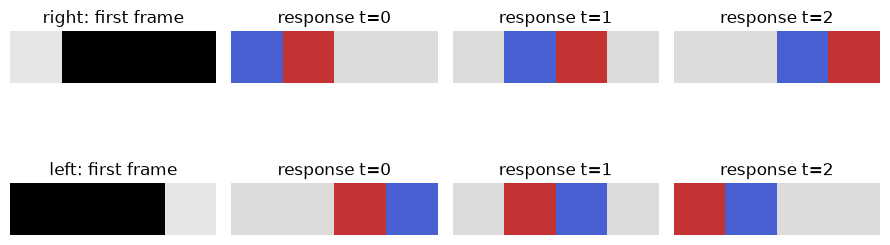

In [34]:
# N=1, C=1, T=4, H=1, W=4. A bright pixel moves to the right.
moving_strip = np.zeros((1, 1, 4, 1, 4))
for t in range(4):
    moving_strip[0, 0, t, 0, t] = 0.9

# moving_strip_left = moving_strip[:, :, ::-1].copy()
moving_strip_left = np.zeros((1, 1, 4, 1, 4))
for t in range(4):
    moving_strip_left[0, 0, t, 0, 3 - t] = 0.9

# (C_out=1, C_in=1, K_t=2, K_h=1, K_w=1): next minus current.
difference_filter = np.array([-1.0, 1.0]).reshape(1, 1, 2, 1, 1)
zero_bias = np.array([0.0])

# run conv3d_forward_naive on forward and time-reversed strips.
right_response = conv3d_forward_naive(moving_strip, difference_filter, zero_bias)
left_response = conv3d_forward_naive(moving_strip_left, difference_filter, zero_bias)

assert right_response.shape == left_response.shape == (1, 1, 3, 1, 4)
# At t=0, a pixel enters position 1 while another leaves position 0.
np.testing.assert_allclose(right_response[0, 0, 0, 0], [-0.9, 0.9, 0.0, 0.0])
np.testing.assert_allclose(left_response[0, 0, 0, 0], [0.0, 0.0, 0.9, -0.9])

fig, axes = plt.subplots(2, 4, figsize=(9, 4))
for row, (strip, response, label) in enumerate(
    ((moving_strip, right_response, "right"),
     (moving_strip[:, :, ::-1], left_response, "left"))
):
    axes[row, 0].imshow(strip[0, 0, 0], cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"{label}: first frame")
    for t in range(3):
        axes[row, t + 1].imshow(response[0, 0, t], cmap="coolwarm", vmin=-1, vmax=1)
        axes[row, t + 1].set_title(f"response t={t}")
for axis in axes.flat:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 6. Video architectures, I3D inflation, and temporal receptive fields

### 6.1 Ways to combine frames

The lecture contrasts several ways to combine video frames:

- **Single-frame CNN:** run a 2D network on each frame; no local temporal mixing inside that network.
- **Early fusion:** stack fixed frame slots as channels. A 2D filter sees all stacked slots at once, but it does not slide in time.
- **Late fusion:** extract frame features, then combine them (average, concatenate, recur, or attend).
- **3D CNN:** a `K_t × K_h × K_w` kernel slides through both time and space, building temporal receptive field layer by layer.

With no bias, parameter counts for an output bank are:

$$\text{2D: } C_{out}C_{in}K_hK_w,\qquad
\text{3D: } C_{out}C_{in}K_tK_hK_w.$$

A 3D layer with temporal size $K_t$ has $K_t$ times as many weights as the corresponding 2D layer. Its output also has a time axis, so intermediate activations can consume substantial memory. A factorized **(2+1)D** block separates a spatial convolution from a temporal convolution; its parameter count depends on the intermediate channel width.

### 6.2 Inflate a pretrained 2D filter into 3D

Image datasets and pretrained 2D CNNs are often much more readily available than pretrained video models. **I3D inflation** provides a simple way to use a learned 2D spatial filter as the starting point for a 3D video filter.

Suppose a simplified 2D filter is $[1,2,1]$. It has spatial dimensions but no temporal dimension. A 3D filter with $K_t=3$ needs three temporal slices, so we copy the 2D filter once for each of the three frame positions:

```text
temporal slice 0: [1, 2, 1]
temporal slice 1: [1, 2, 1]
temporal slice 2: [1, 2, 1]
```

If the three input frames are identical, adding these three responses would make the result three times larger than the original 2D response. To preserve its scale, divide every copy by $K_t=3$:

```text
slice 0: [1/3, 2/3, 1/3]
slice 1: [1/3, 2/3, 1/3]
slice 2: [1/3, 2/3, 1/3]
          ----------------
sum:     [  1,   2,   1]
```

Thus, for a temporally constant video, the temporal slices sum to the original 2D filter and initially reproduce its response (away from padding boundaries). Inflation is only an **initialization**: during video training, the temporal slices can become different and learn motion-sensitive patterns.

In tensor form, a filter bank changes from $(C_{out},C_{in},K_h,K_w)$ to $(C_{out},C_{in},K_t,K_h,K_w)$. The code below inserts a temporal axis, repeats the 2D weights $K_t$ times, and divides them by $K_t$.

### 6.3 Temporal receptive field

The **temporal receptive field** is the number of original input frames that can influence one feature. One convolution with $K_t=3$ sees three adjacent frames.

A second $K_t=3$ layer combines three neighboring first-layer features:

```text
first-layer feature 0 sees frames 0, 1, 2
first-layer feature 1 sees frames 1, 2, 3
first-layer feature 2 sees frames 2, 3, 4
                                 ---------
combined coverage:             frames 0–4
```

Therefore, with temporal stride 1 and no dilation:

```text
one K_t=3 layer:    receptive field 3
two K_t=3 layers:   receptive field 5
three K_t=3 layers: receptive field 7
```

Each new layer adds $K_t-1$ frames, so $R_{new}=R_{old}+K_t-1$ in this stride-1 case. Deeper local filters can therefore combine information across a longer time interval.

### 6.4 Temporal jump

The **temporal jump** says how far apart two adjacent output features are when measured in original input frames. With temporal stride 1, neighboring outputs move by one frame, so the jump is 1. With temporal stride 2 and $K_t=3$, consecutive windows start two frames apart:

```text
output 0 uses frames 0, 1, 2
output 1 uses frames 2, 3, 4
output 2 uses frames 4, 5, 6
```

The jump is therefore 2. A larger stride increases temporal coverage more quickly, but it produces fewer outputs and may skip fine motion details.

In [36]:
c_in, c_out, kh, kw, kt = 3, 8, 3, 3, 3
count_2d = c_out * c_in * kh * kw
count_3d = c_out * c_in * kt * kh * kw
assert count_3d == kt * count_2d
print(f"2D weights: {count_2d}; 3D weights: {count_3d}")

kernel_2d = np.arange(c_out * c_in * kh * kw).reshape(c_out, c_in, kh, kw)
inflated_kernel = np.repeat(kernel_2d[:, :, None], kt, axis=2) / kt
assert inflated_kernel.shape == (c_out, c_in, kt, kh, kw)
np.testing.assert_allclose(inflated_kernel.sum(axis=2), kernel_2d)
print("Inflated temporal slices sum back to the original 2D kernel.")

2D weights: 216; 3D weights: 648
Inflated temporal slices sum back to the original 2D kernel.


## Reflection

Answer briefly in your own words.

1. What are the axes of a Conv3D input, filter bank, and output?
2. Why does the naïve forward pass sum over input channels and all three kernel axes?
3. How is an early-fusion 2D filter different from a 3D filter that slides in time?
4. What did the tiny `(1,2,4)` example show about temporal order?
5. Why is the temporal-difference response spatially localized rather than a complete direction classifier?
6. Why can a 3D CNN be more expensive than a 2D CNN?
7. What is the idea behind inflating a pretrained 2D filter into 3D?
8. How do stacked temporal convolutions gain a larger temporal receptive field?

### Answers

1. input has previous layer or input numbers and channels, frames number, height and width. filter bank has number of filters, kernel size for time, height and width.

input:       (N, C_in, T, H, W)

filter bank: (C_out, C_in, K_t, K_h, K_w)

output:      (N, C_out, T_out, H_out, W_out)

2. One output is the dot product between the complete input patch and one filter. Therefore, it must sum every product across input channels, time, height, and width.
3. early fusion compress time dimension into channels. early fusion uses fixed temporal slots as channels and does not slide through time. A 3D filter is reused at multiple temporal positions.
4. The example was about temporal order. The filter produced -3 for (1,2,4) but +3 for the reversed sequence (4,2,1). Thus, a temporal filter can distinguish sequences containing the same values in different orders.
5. same kernel check only local areas and slides through space and time. Each response describes change at one spatial position over two adjacent frames. It does not combine evidence across the entire moving trajectory, so it is not yet a complete direction classifier.
6. time dimensions increase number of required parameters and calculations. A 3D kernel contains K_t times more weights than its corresponding 2D kernel, performs more calculations, and retains time in intermediate activations.
7. idea is to repeat the pretrained 2D filter across the temporal axis and usually divide each copy by K_t. Their temporal sum then equals the original 2D filter.
8. A deeper temporal layer combines neighboring features that already depend on overlapping input-frame windows. For example, two stride-1 K_t=3 layers cover five original frames: 0–2, 1–3, and 2–4 combine into coverage 0–4.